# Task 2

The code works in log-price space and compares five interpolation models around each gap: AR(1), Random walk, GARCH(1,1), an AR-X extension using correlation plus Granger information from Task 1, and a simpler AR-X correlation-only extension.

The Task 1 extensions use cross-series relationships from the return correlation and Granger-causality analysis. The first AR-X model uses both significant Granger lags and strong correlations. The second AR-X model is deliberately stricter: it only uses highly correlated series, such as guitars/slingshots and gurkor/water, with lag 1 as a leakage-safe exogenous regressor.

For each target series, parameters are estimated from observed data before and after the gap. The missing block is then reconstructed conditional on the observed left and right endpoints, and 95% intervals are computed for all days.

The methods are compared with a leakage-safe backtest based on synthetic 50-day gaps placed inside observed parts of the series.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize
from scipy.stats import norm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tools.sm_exceptions import ValueWarning

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# AutoReg is used only for coefficient estimation; forecasts are produced manually below.
# Statsmodels may warn about unsupported indexes after missing rows are dropped, which is harmless here.
warnings.filterwarnings(
    "ignore",
    message="An unsupported index was provided.*",
    category=ValueWarning,
)

# shared settings
DATA_PATH = Path("../augmented_data/spiff_data_cleaned.csv")
TAIL_MISSING = 200
GAP_LENGTH = 50
LOCAL_WINDOW = 252
Z_95 = norm.ppf(0.975)

# keep the final forecast tail out of the interpolation task
data = pd.read_csv(DATA_PATH, index_col="day")
known_data = data.iloc[:-TAIL_MISSING].copy()

print(f"Data shape: {data.shape}")
print(f"Rows before the shared forecasting tail: {known_data.shape[0]}")
display(data.head())


Data shape: (5456, 7)
Rows before the shared forecasting tail: 5256


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.1547,2.7943,2.1365,10.6537,3.3249,3.8961,7.7559
2,6.1896,2.8431,2.1136,10.6745,3.3557,3.8999,7.7813
3,6.1686,2.8396,2.1163,10.8224,3.3365,3.8974,7.8862
4,6.1564,2.8234,2.0961,10.8488,3.2883,3.9012,7.8481
5,6.1249,2.8328,2.0998,10.8607,3.3037,3.9054,7.8830


In [2]:
def contiguous_groups(mask):
    # split missing values into contiguous blocks
    indices = np.flatnonzero(mask.to_numpy())
    if len(indices) == 0:
        return []
    split_points = np.where(np.diff(indices) > 1)[0] + 1
    return np.split(indices, split_points)


def find_internal_gap(series, tail_missing = TAIL_MISSING):
    missing_groups = contiguous_groups(series.isna())
    internal_groups = [group for group in missing_groups if group[-1] < len(series) - tail_missing]
    return internal_groups[0]


# store gap location for each series
gap_overview_rows = []
gap_map: dict[str, np.ndarray] = {}
for column in data.columns:
    gap = find_internal_gap(data[column])
    gap_map[column] = gap
    gap_overview_rows.append(
        {
            "series": column,
            "gap_start_day": int(data.index[gap[0]]),
            "gap_end_day": int(data.index[gap[-1]]),
            "gap_length": len(gap),
        }
    )

gap_overview = pd.DataFrame(gap_overview_rows)
display(gap_overview)


,series,gap_start_day,gap_end_day,gap_length
0,gurkor,199,248,50
1,guitars,399,448,50
2,slingshots,599,648,50
3,stocks,799,848,50
4,sugar,999,1048,50
5,water,1199,1248,50
6,tranquillity,1399,1448,50


## Task 1 relationships used in Task 2
The earlier univariate-only setup was too conservative: correlations around 0.5 are meaningful for this data. Therefore, this notebook now uses Task 1 in two AR-X variants.

The first variant, **AR-X (Task 1 exog)**, keeps two types of Task 1 evidence:
- strong absolute log-return correlations, using a threshold of 0.50;
- significant Granger-causality lags at the 5% level.

The second variant, **AR-X (correlation-only)**, only uses highly correlated pairs above the same threshold. It intentionally ignores Granger-only relationships because those can be noisier and harder to interpret in a small local interpolation model.

Both AR-X variants add related series as lagged exogenous variables. This keeps the interpolation leakage-safe because the regressors at day `t` only use other-series values from earlier days.


In [3]:
# compare log return dependence across series and convert Task 1 findings into exogenous lag choices
log_returns_data = np.log(known_data).diff()
log_return_corr = log_returns_data.dropna().corr()

display(log_return_corr.round(3))

CORR_THRESHOLD = 0.50
GRANGER_MAX_LAG = 10
GRANGER_ALPHA = 0.05
MAX_EXOG_LAGS_PER_TARGET = 4


def compute_granger_dependency_table(log_returns, max_lag=GRANGER_MAX_LAG, alpha=GRANGER_ALPHA):
    # row interpretation: target is tested as being Granger-caused by driver
    rows = []
    columns = list(log_returns.columns)

    for target in columns:
        for driver in columns:
            if target == driver:
                continue

            pair = log_returns[[target, driver]].dropna()
            if len(pair) < max(50, 3 * max_lag):
                continue

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    test_result = grangercausalitytests(pair, maxlag=max_lag, verbose=False)
            except Exception:
                continue

            p_values = {
                lag: float(test_result[lag][0]["ssr_chi2test"][1])
                for lag in range(1, max_lag + 1)
            }
            significant_lags = [lag for lag, p_value in p_values.items() if p_value < alpha]

            if significant_lags:
                significant_lags = sorted(significant_lags, key=lambda lag: p_values[lag])
                rows.append(
                    {
                        "target": target,
                        "driver": driver,
                        "significant_lags": significant_lags,
                        "best_lag": significant_lags[0],
                        "min_p_value": p_values[significant_lags[0]],
                    }
                )

    return pd.DataFrame(rows)


def build_task1_exog_lag_map(correlation_matrix, granger_table, corr_threshold=CORR_THRESHOLD):
    # combine strong correlations and causality evidence into a compact lagged-exog specification
    candidate_rows = []
    columns = list(correlation_matrix.columns)

    for target in columns:
        for driver in columns:
            if target == driver:
                continue

            corr_value = float(correlation_matrix.loc[target, driver])
            abs_corr = abs(corr_value)
            granger_match = granger_table[
                (granger_table["target"] == target) & (granger_table["driver"] == driver)
            ]

            use_from_corr = abs_corr >= corr_threshold
            use_from_granger = len(granger_match) > 0

            if not (use_from_corr or use_from_granger):
                continue

            if use_from_granger:
                selected_lags = list(granger_match.iloc[0]["significant_lags"][:2])
                min_p_value = float(granger_match.iloc[0]["min_p_value"])
                evidence = "correlation + Granger" if use_from_corr else "Granger"
            else:
                selected_lags = [1]
                min_p_value = np.nan
                evidence = "correlation"

            # prioritize strong correlations and very small Granger p-values, then cap model size
            p_score = 0.0 if np.isnan(min_p_value) else -np.log10(max(min_p_value, 1e-12)) / 10
            score = abs_corr + p_score

            for lag in selected_lags:
                candidate_rows.append(
                    {
                        "target": target,
                        "driver": driver,
                        "lag": int(lag),
                        "corr": corr_value,
                        "abs_corr": abs_corr,
                        "min_granger_p": min_p_value,
                        "evidence": evidence,
                        "score": score,
                    }
                )

    candidate_table = pd.DataFrame(candidate_rows)
    if candidate_table.empty:
        return {}, candidate_table, candidate_table

    selected_table = (
        candidate_table
        .sort_values(["target", "score", "abs_corr", "lag"], ascending=[True, False, False, True])
        .groupby("target", as_index=False)
        .head(MAX_EXOG_LAGS_PER_TARGET)
        .reset_index(drop=True)
    )

    lag_map = {
        target: group[["driver", "lag"]].to_dict("records")
        for target, group in selected_table.groupby("target")
    }
    return lag_map, candidate_table, selected_table


def build_correlation_only_exog_lag_map(correlation_matrix, corr_threshold=CORR_THRESHOLD):
    # simpler Task 1 variant: use only strongly correlated pairs, all at lag 1
    candidate_rows = []
    columns = list(correlation_matrix.columns)

    for target in columns:
        for driver in columns:
            if target == driver:
                continue

            corr_value = float(correlation_matrix.loc[target, driver])
            abs_corr = abs(corr_value)
            if abs_corr < corr_threshold:
                continue

            candidate_rows.append(
                {
                    "target": target,
                    "driver": driver,
                    "lag": 1,
                    "corr": corr_value,
                    "abs_corr": abs_corr,
                    "evidence": "correlation-only",
                }
            )

    selected_table = pd.DataFrame(candidate_rows)
    if selected_table.empty:
        return {}, selected_table

    selected_table = selected_table.sort_values(
        ["target", "abs_corr", "driver"],
        ascending=[True, False, True],
    ).reset_index(drop=True)

    lag_map = {
        target: group[["driver", "lag"]].to_dict("records")
        for target, group in selected_table.groupby("target")
    }
    return lag_map, selected_table


task1_granger_table = compute_granger_dependency_table(log_returns_data)
TASK1_EXOGENOUS_LAGS, task1_exog_candidates, task1_selected_exog = build_task1_exog_lag_map(
    log_return_corr,
    task1_granger_table,
)
TASK1_CORRELATION_ONLY_LAGS, task1_corr_only_selected_exog = build_correlation_only_exog_lag_map(
    log_return_corr,
)

print("Task 1 Granger-causality relationships found:")
display(task1_granger_table)

print("Selected lagged exogenous variables for AR-X (Task 1 exog):")
display(
    task1_selected_exog.drop(columns="score").sort_values(["target", "driver", "lag"])
)
print(TASK1_EXOGENOUS_LAGS)

print("Selected lagged exogenous variables for AR-X (correlation-only):")
display(task1_corr_only_selected_exog.sort_values(["target", "driver", "lag"]))
print(TASK1_CORRELATION_ONLY_LAGS)


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.0000,-0.2590,-0.2290,-0.0430,-0.0720,0.5740,-0.1380
guitars,-0.2590,1.0000,0.5300,0.0220,0.2070,-0.2450,0.2300
slingshots,-0.2290,0.5300,1.0000,0.0170,0.1170,-0.2110,0.1920
stocks,-0.0430,0.0220,0.0170,1.0000,-0.0140,-0.0430,0.0080
sugar,-0.0720,0.2070,0.1170,-0.0140,1.0000,-0.0790,0.1290
water,0.5740,-0.2450,-0.2110,-0.0430,-0.0790,1.0000,-0.1610
tranquillity,-0.1380,0.2300,0.1920,0.0080,0.1290,-0.1610,1.0000


Task 1 Granger-causality relationships found:


,target,driver,significant_lags,best_lag,min_p_value
0,gurkor,sugar,"[9, 10, 5]",9,0.0118
1,gurkor,water,"[5, 6, 4, 7, 8, 9]",5,0.0062
2,guitars,gurkor,"[3, 1, 2, 4]",3,0.0178
3,guitars,slingshots,"[2, 3, 1, 4, 5, 6, 7, 8, 9, 10]",2,0.0000
4,guitars,sugar,"[1, 3, 2, 4]",1,0.0159
5,guitars,tranquillity,[1],1,0.0258
6,slingshots,guitars,"[7, 8, 1, 9, 3, 10, 2, 6, 4, 5]",7,0.0006
7,slingshots,sugar,"[4, 8, 10, 9, 7]",4,0.0035
8,sugar,gurkor,"[1, 3, 4, 2, 5, 6, 7, 8, 9, 10]",1,0.0000
9,sugar,guitars,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",1,0.0000


Selected lagged exogenous variables for AR-X (Task 1 exog):


,target,driver,lag,corr,abs_corr,min_granger_p,evidence
2,guitars,gurkor,1,-0.2589,0.2589,0.0178,Granger
3,guitars,gurkor,3,-0.2589,0.2589,0.0178,Granger
0,guitars,slingshots,2,0.5305,0.5305,0.0000,correlation + Granger
1,guitars,slingshots,3,0.5305,0.5305,0.0000,correlation + Granger
6,gurkor,sugar,9,-0.0723,0.0723,0.0118,Granger
...,...,...,...,...,...,...,...
19,tranquillity,sugar,4,0.1291,0.1291,0.0041,Granger
20,water,gurkor,1,0.5740,0.5740,0.0000,correlation + Granger
21,water,gurkor,2,0.5740,0.5740,0.0000,correlation + Granger
22,water,sugar,9,-0.0785,0.0785,0.0000,Granger


{'guitars': [{'driver': 'slingshots', 'lag': 2}, {'driver': 'slingshots', 'lag': 3}, {'driver': 'gurkor', 'lag': 1}, {'driver': 'gurkor', 'lag': 3}], 'gurkor': [{'driver': 'water', 'lag': 5}, {'driver': 'water', 'lag': 6}, {'driver': 'sugar', 'lag': 9}, {'driver': 'sugar', 'lag': 10}], 'slingshots': [{'driver': 'guitars', 'lag': 7}, {'driver': 'guitars', 'lag': 8}, {'driver': 'sugar', 'lag': 4}, {'driver': 'sugar', 'lag': 8}], 'sugar': [{'driver': 'guitars', 'lag': 1}, {'driver': 'guitars', 'lag': 2}, {'driver': 'tranquillity', 'lag': 1}, {'driver': 'tranquillity', 'lag': 2}], 'tranquillity': [{'driver': 'slingshots', 'lag': 1}, {'driver': 'slingshots', 'lag': 2}, {'driver': 'sugar', 'lag': 3}, {'driver': 'sugar', 'lag': 4}], 'water': [{'driver': 'gurkor', 'lag': 1}, {'driver': 'gurkor', 'lag': 2}, {'driver': 'sugar', 'lag': 9}, {'driver': 'sugar', 'lag': 10}]}
Selected lagged exogenous variables for AR-X (correlation-only):


,target,driver,lag,corr,abs_corr,evidence
0,guitars,slingshots,1,0.5305,0.5305,correlation-only
1,gurkor,water,1,0.5740,0.5740,correlation-only
2,slingshots,guitars,1,0.5305,0.5305,correlation-only
3,water,gurkor,1,0.5740,0.5740,correlation-only


{'guitars': [{'driver': 'slingshots', 'lag': 1}], 'gurkor': [{'driver': 'water', 'lag': 1}], 'slingshots': [{'driver': 'guitars', 'lag': 1}], 'water': [{'driver': 'gurkor', 'lag': 1}]}


## Interpolation models

- **AR(1)**: estimates a local mean-reverting process and fills the gap with the conditional Gaussian predictor. The AR coefficient is estimated with `statsmodels.tsa.ar_model.AutoReg`.
- **Random walk**: treats log-returns as i.i.d. innovations and interpolates the gap as a variance bridge between the two observed endpoints.
- **GARCH(1,1)**: uses the same bridge idea as the random walk model, but allows the innovation variance to change over time through a local volatility recursion.
- **AR-X (Task 1 exog)**: fits a statsmodels autoregression with selected Task 1 lagged exogenous variables from both strong correlations and significant Granger tests.
- **AR-X (correlation-only)**: fits the same statsmodels autoregression but only adds lag-1 variables from highly correlated Task 1 pairs. This is the stricter version that directly tests whether guitars/slingshots and gurkor/water improve the interpolation without extra Granger-only predictors.

All five models produce point estimates and 95% intervals in log-price space. The AR-X forecasts are endpoint-corrected so the imputed paths still connect exactly to the observed right endpoint.


In [4]:
MIN_AR1_PAIRS = 20
MIN_RETURN_PAIRS = 20
MIN_GARCH_PAIRS = 40
PHI_CLIP = 0.98
RIDGE = 1e-10
GARCH_PERSISTENCE_CAP = 0.995
INTERPOLATION_METHODS = ("ar1", "random_walk", "garch", "arx_task1", "arx_corr_only")
ARX_LAGS = 1

# helper functions for local parameter estimation and endpoint conditioning
METHOD_LABELS = {
    "ar1": "AR(1)",
    "random_walk": "Random walk",
    "garch": "GARCH(1,1)",
    "arx_task1": "AR-X (Task 1 exog)",
    "arx_corr_only": "AR-X (correlation-only)",
}


def _observed_series_without_tail(series, tail_missing = TAIL_MISSING):
    return series.iloc[:-tail_missing] if series.isna().sum() > tail_missing else series


def _valid_log_block(series):
    block = np.log(series.dropna())
    if len(block) < 2:
        return pd.Series(dtype=float)
    return block


def _get_local_log_blocks(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # collect observed log-price blocks on both sides of the gap
    left_block = _valid_log_block(series.iloc[max(0, gap_start - window):gap_start])
    right_block = _valid_log_block(series.iloc[gap_end + 1:min(len(series), gap_end + 1 + window)])

    sample_parts = [block for block in (left_block, right_block) if len(block) > 0]
    sample = pd.concat(sample_parts) if sample_parts else pd.Series(dtype=float)
    blocks = [block for block in (left_block, right_block) if len(block) >= 2]

    return left_block, right_block, sample, blocks


def _returns_from_blocks(blocks):
    return_parts = [np.diff(block.to_numpy()) for block in blocks if len(block) >= 2]
    if not return_parts:
        return np.array([])
    return np.concatenate(return_parts)


def _fallback_ar1_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # closed-form backup in case AutoReg cannot fit a local sample
    left_block, right_block, sample, blocks = _get_local_log_blocks(series, gap_start, gap_end, window=window)

    x_prev_parts = [block.iloc[:-1].to_numpy() for block in blocks if len(block) >= 2]
    x_curr_parts = [block.iloc[1:].to_numpy() for block in blocks if len(block) >= 2]

    x_prev = np.concatenate(x_prev_parts)
    x_curr = np.concatenate(x_curr_parts)

    mu = float(sample.mean())
    x_prev_centered = x_prev - mu
    x_curr_centered = x_curr - mu

    denom = float(np.dot(x_prev_centered, x_prev_centered))
    phi = 0.0 if denom <= 0 else float(np.dot(x_prev_centered, x_curr_centered) / denom)
    phi = float(np.clip(phi, -PHI_CLIP, PHI_CLIP))

    residuals = x_curr_centered - phi * x_prev_centered
    sigma_eps = float(np.std(residuals, ddof=1))
    sigma_eps = max(sigma_eps, 1e-8)

    return mu, phi, sigma_eps


def _extract_autoreg_phi(result, lag=1):
    params = result.params
    lag_suffix = f".L{lag}"
    matches = [name for name in params.index if str(name).endswith(lag_suffix)]
    if not matches:
        return np.nan
    return float(params[matches[0]])


def estimate_local_ar1_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # fit AR(1) with statsmodels AutoReg on observed local log prices around the gap
    local_start = max(0, gap_start - window)
    local_end = min(len(series), gap_end + 1 + window)
    local_log = np.log(series.iloc[local_start:local_end]).reset_index(drop=True)
    local_log.name = series.name or "target"

    try:
        if local_log.notna().sum() < MIN_AR1_PAIRS:
            raise ValueError("not enough local observations for AutoReg")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ValueWarning)
            model = AutoReg(local_log, lags=1, trend="c", old_names=False, missing="drop")
            result = model.fit()
        phi = float(np.clip(_extract_autoreg_phi(result, lag=1), -PHI_CLIP, PHI_CLIP))
        const = float(result.params.get("const", 0.0))
        local_mean = float(local_log.mean())
        mu = const / max(1 - phi, 1e-6) if abs(phi) < PHI_CLIP else local_mean
        if not np.isfinite(mu):
            mu = local_mean
        sigma_eps = float(np.sqrt(max(result.sigma2, 1e-12)))
        return mu, phi, sigma_eps
    except Exception:
        return _fallback_ar1_params(series, gap_start, gap_end, window=window)


def estimate_local_random_walk_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # estimate drift and volatility from local log returns
    _, _, _, blocks = _get_local_log_blocks(series, gap_start, gap_end, window=window)
    returns = _returns_from_blocks(blocks)

    drift = float(np.mean(returns))
    sigma_return = float(np.std(returns, ddof=1))
    sigma_return = max(sigma_return, 1e-8)
    return drift, sigma_return


def _garch_filter(centered_returns, omega, alpha, beta, initial_variance = None):
    # propagate the conditional variance recursion forward
    if initial_variance is None:
        unconditional = omega / max(1 - alpha - beta, 1e-6)
        initial_variance = max(float(np.var(centered_returns, ddof=1)) if len(centered_returns) > 1 else unconditional, 1e-8)
    variances = np.empty(len(centered_returns), dtype=float)
    prev_var = max(initial_variance, 1e-8)
    for i, shock in enumerate(centered_returns):
        prev_var = omega + alpha * shock**2 + beta * prev_var
        variances[i] = max(prev_var, 1e-8)
    return variances


def estimate_local_garch_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # fit a simple garch recursion to local log returns
    left_block, _, _, blocks = _get_local_log_blocks(series, gap_start, gap_end, window=window)
    returns = _returns_from_blocks(blocks)

    sample_var = max(float(np.var(returns, ddof=1)), 1e-8)

    def objective(params):
        # gaussian quasi-likelihood under the variance recursion
        drift, omega, alpha, beta = params
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= GARCH_PERSISTENCE_CAP:
            return np.inf
        centered = returns - drift
        variances = _garch_filter(centered, omega, alpha, beta, initial_variance=sample_var)
        return 0.5 * float(np.sum(np.log(variances) + centered**2 / variances))

    start = np.array([
        float(np.mean(returns)),
        sample_var * 0.05,
        0.08,
        0.88,
    ])
    bounds = [
        (None, None),
        (1e-8, None),
        (0.0, 0.4),
        (0.0, 0.999),
    ]
    result = minimize(objective, start, method="L-BFGS-B", bounds=bounds)

    if result.success:
        drift, omega, alpha, beta = map(float, result.x)
        if alpha + beta >= GARCH_PERSISTENCE_CAP:
            scale = (GARCH_PERSISTENCE_CAP - 1e-4) / (alpha + beta)
            alpha *= scale
            beta *= scale
    else:
        drift = float(np.mean(returns))
        alpha, beta = 0.08, 0.88
        omega = max(sample_var * (1 - alpha - beta), 1e-8)

    left_returns = np.diff(left_block.to_numpy()) if len(left_block) >= 2 else returns
    left_centered = left_returns - drift
    left_variances = _garch_filter(left_centered, omega, alpha, beta, initial_variance=sample_var)
    last_variance = float(left_variances[-1]) if len(left_variances) else sample_var
    long_run_variance = float(omega / max(1 - alpha - beta, 1e-6))

    return {
        "drift_return": drift,
        "garch_omega": omega,
        "garch_alpha": alpha,
        "garch_beta": beta,
        "last_variance": last_variance,
        "long_run_sigma": float(np.sqrt(max(long_run_variance, 1e-8))),
    }


def ar1_conditional_prices(left_log_price, right_log_price, mu, phi, sigma_eps, gap_length, z_value = Z_95):
    # condition the missing log prices on both observed endpoints
    steps = np.arange(1, gap_length + 1)
    observed_steps = np.array([0, gap_length + 1])

    gamma0 = sigma_eps**2 / max(1 - phi**2, 1e-6)
    sigma_oo = gamma0 * (phi ** np.abs(observed_steps[:, None] - observed_steps[None, :]))
    sigma_mo = gamma0 * (phi ** np.abs(steps[:, None] - observed_steps[None, :]))
    sigma_mm = gamma0 * (phi ** np.abs(steps[:, None] - steps[None, :]))

    centered_observed = np.array([left_log_price - mu, right_log_price - mu])
    inv_sigma_oo = np.linalg.inv(sigma_oo + RIDGE * np.eye(len(observed_steps)))

    mean_log = mu + sigma_mo @ inv_sigma_oo @ centered_observed
    cov_log = sigma_mm - sigma_mo @ inv_sigma_oo @ sigma_mo.T
    std_log = np.sqrt(np.clip(np.diag(cov_log), 0.0, None))

    estimate = np.exp(mean_log)
    lower_95 = np.exp(mean_log - z_value * std_log)
    upper_95 = np.exp(mean_log + z_value * std_log)
    return estimate, lower_95, upper_95, std_log


def variance_bridge_prices(left_log_price, right_log_price, innovation_variances, z_value = Z_95):
    # build a bridge between the observed endpoints
    innovation_variances = np.asarray(innovation_variances, dtype=float)
    total_variance = float(np.sum(innovation_variances))
    cumulative_variance = np.cumsum(innovation_variances)[:-1]

    if total_variance <= 0:
        weights = np.linspace(1 / len(innovation_variances), (len(innovation_variances) - 1) / len(innovation_variances), len(innovation_variances) - 1)
        std_log = np.zeros(len(weights))
    else:
        weights = cumulative_variance / total_variance
        conditional_variance = cumulative_variance - cumulative_variance**2 / total_variance
        std_log = np.sqrt(np.clip(conditional_variance, 0.0, None))

    mean_log = left_log_price + weights * (right_log_price - left_log_price)
    estimate = np.exp(mean_log)
    lower_95 = np.exp(mean_log - z_value * std_log)
    upper_95 = np.exp(mean_log + z_value * std_log)
    return estimate, lower_95, upper_95, std_log


def forecast_garch_innovation_variances(last_variance, omega, alpha, beta, horizon):
    # extend the garch variance path across the missing block
    forecast = np.empty(horizon, dtype=float)
    current_variance = max(last_variance, 1e-8)
    persistence = min(alpha + beta, GARCH_PERSISTENCE_CAP)
    for step in range(horizon):
        current_variance = omega + persistence * current_variance
        forecast[step] = max(current_variance, 1e-8)
    return forecast


def _make_task1_exog_frame(panel_data, target_name, exog_lag_map = None):
    # build lagged log-price exogenous regressors selected from Task 1
    if exog_lag_map is None:
        exog_lag_map = TASK1_EXOGENOUS_LAGS

    columns = {}
    for spec in exog_lag_map.get(target_name, []):
        driver = spec["driver"]
        lag = int(spec["lag"])
        if driver not in panel_data.columns:
            continue
        columns[f"{driver}_lag{lag}"] = np.log(panel_data[driver]).shift(lag)

    if not columns:
        return pd.DataFrame(index=panel_data.index)
    return pd.DataFrame(columns, index=panel_data.index)


def _extract_autoreg_params(result, ar_lags, exog_columns):
    params = result.params
    const = float(params.get("const", 0.0))
    ar_params = []
    for lag in range(1, ar_lags + 1):
        ar_params.append(_extract_autoreg_phi(result, lag=lag))

    exog_params = np.array([float(params.get(col, 0.0)) for col in exog_columns], dtype=float)
    sigma_eps = float(np.sqrt(max(result.sigma2, 1e-12)))
    return const, np.array(ar_params, dtype=float), exog_params, sigma_eps


def _dynamic_autoreg_forecast_from_params(y_log, x_exog, start, end, const, ar_params, exog_params):
    # recursive dynamic prediction using coefficients estimated by statsmodels AutoReg
    y_values = y_log.to_numpy(dtype=float).copy()
    forecasts = []
    max_lag = len(ar_params)

    for t in range(start, end + 1):
        if t - max_lag < 0:
            raise ValueError("not enough pre-gap observations for dynamic AR forecast")
        x_t = x_exog.iloc[t].to_numpy(dtype=float) if len(exog_params) else np.array([])
        if np.any(~np.isfinite(x_t)):
            raise ValueError("missing exogenous value in AR-X forecast window")

        ar_part = 0.0
        for lag, phi in enumerate(ar_params, start=1):
            lagged_y = y_values[t - lag]
            if not np.isfinite(lagged_y):
                raise ValueError("missing autoregressive value in AR-X forecast window")
            ar_part += phi * lagged_y

        y_hat = const + ar_part + float(np.dot(exog_params, x_t))
        y_values[t] = y_hat
        forecasts.append(y_hat)

    return np.array(forecasts, dtype=float)


def arx_task1_conditional_prices(
    series,
    panel_data,
    gap_start,
    gap_end,
    window = LOCAL_WINDOW,
    z_value = Z_95,
    exog_lag_map = None,
    model_source = "Task 1 exog",
):
    # use statsmodels AutoReg with lagged exogenous regressors, then endpoint-correct the forecast path
    target_name = series.name
    gap_length = gap_end - gap_start + 1
    if exog_lag_map is None:
        exog_lag_map = TASK1_EXOGENOUS_LAGS
    exog_specs = exog_lag_map.get(target_name, [])

    try:
        if not exog_specs:
            raise ValueError(f"no {model_source} exogenous regressors selected")

        local_start = max(0, gap_start - window)
        local_end = min(len(series), gap_end + 1 + window)
        local_gap_start = gap_start - local_start
        local_gap_end = gap_end - local_start

        local_series = series.iloc[local_start:local_end].copy()
        local_panel = panel_data.iloc[local_start:local_end].copy()
        y_log = np.log(local_series).reset_index(drop=True)
        y_log.name = target_name or "target"
        x_exog = _make_task1_exog_frame(local_panel, target_name, exog_lag_map=exog_lag_map).reset_index(drop=True)

        if x_exog.empty:
            raise ValueError("selected exogenous regressors are unavailable")
        if y_log.notna().sum() < MIN_AR1_PAIRS + len(x_exog.columns):
            raise ValueError("not enough local observations for AR-X")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ValueWarning)
            model = AutoReg(y_log, lags=ARX_LAGS, exog=x_exog, trend="c", old_names=False, missing="drop")
            result = model.fit()
        const, ar_params, exog_params, sigma_eps = _extract_autoreg_params(result, ARX_LAGS, x_exog.columns)

        # include the observed right endpoint in the dynamic forecast only to compute an endpoint correction
        model_path = _dynamic_autoreg_forecast_from_params(
            y_log=y_log,
            x_exog=x_exog,
            start=local_gap_start,
            end=local_gap_end + 1,
            const=const,
            ar_params=ar_params,
            exog_params=exog_params,
        )
        model_gap = model_path[:gap_length]
        model_right_endpoint = model_path[-1]
        right_log_price = float(np.log(series.iloc[gap_end + 1]))

        bridge_weights = np.arange(1, gap_length + 1) / (gap_length + 1)
        mean_log = model_gap + bridge_weights * (right_log_price - model_right_endpoint)

        # interval approximation: bridge the AutoReg residual variance across the missing block
        innovation_variances = np.full(gap_length + 1, sigma_eps**2)
        _, _, _, std_log = variance_bridge_prices(0.0, 0.0, innovation_variances, z_value=z_value)

        estimate = np.exp(mean_log)
        lower_95 = np.exp(mean_log - z_value * std_log)
        upper_95 = np.exp(mean_log + z_value * std_log)
        return estimate, lower_95, upper_95, std_log, {
            "arx_used": True,
            "arx_source": model_source,
            "arx_terms": ", ".join(x_exog.columns),
            "arx_sigma": sigma_eps,
        }
    except Exception as exc:
        # robust fallback so every series can still be evaluated under the same method name
        left_log_price = float(np.log(series.iloc[gap_start - 1]))
        right_log_price = float(np.log(series.iloc[gap_end + 1]))
        drift, sigma_return = estimate_local_random_walk_params(series, gap_start, gap_end, window=window)
        innovation_variances = np.full(gap_length + 1, sigma_return**2)
        estimate, lower_95, upper_95, std_log = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
            z_value=z_value,
        )
        return estimate, lower_95, upper_95, std_log, {
            "arx_used": False,
            "arx_source": model_source,
            "arx_terms": "fallback: random walk",
            "arx_sigma": sigma_return,
            "arx_fallback_reason": str(exc)[:120],
        }


def interpolate_internal_gap(series, method = "ar1"):
    # run one interpolation model for one series
    gap = gap_map[series.name]
    gap_start, gap_end = int(gap[0]), int(gap[-1])
    gap_length = len(gap)
    log_series = np.log(series)
    left_log_price = float(log_series.iloc[gap_start - 1])
    right_log_price = float(log_series.iloc[gap_end + 1])

    if method == "ar1":
        mu, phi, sigma_eps = estimate_local_ar1_params(series, gap_start, gap_end)
        estimate, lower_95, upper_95, std_log = ar1_conditional_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            mu=mu,
            phi=phi,
            sigma_eps=sigma_eps,
            gap_length=gap_length,
        )
        params = {
            "local_mu_log_price": mu,
            "local_phi": phi,
            "innovation_sigma": sigma_eps,
        }
    elif method == "random_walk":
        drift, sigma_return = estimate_local_random_walk_params(series, gap_start, gap_end)
        innovation_variances = np.full(gap_length + 1, sigma_return**2)
        estimate, lower_95, upper_95, std_log = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        params = {
            "drift_return": drift,
            "return_sigma": sigma_return,
        }
    elif method == "garch":
        params = estimate_local_garch_params(series, gap_start, gap_end)
        innovation_variances = forecast_garch_innovation_variances(
            last_variance=params["last_variance"],
            omega=params["garch_omega"],
            alpha=params["garch_alpha"],
            beta=params["garch_beta"],
            horizon=gap_length + 1,
        )
        estimate, lower_95, upper_95, std_log = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        # drop the latent state after it has been used for forecasting
        params = {
            key: value
            for key, value in params.items()
            if key != "last_variance"
        }
    elif method in ("arx_task1", "arx_corr_only"):
        exog_lag_map = TASK1_EXOGENOUS_LAGS if method == "arx_task1" else TASK1_CORRELATION_ONLY_LAGS
        model_source = "Task 1 correlation + Granger" if method == "arx_task1" else "Task 1 correlation-only"
        estimate, lower_95, upper_95, std_log, params = arx_task1_conditional_prices(
            series=series,
            panel_data=data,
            gap_start=gap_start,
            gap_end=gap_end,
            exog_lag_map=exog_lag_map,
            model_source=model_source,
        )
    else:
        raise ValueError(f"Unknown method: {method}")

    gap_table = pd.DataFrame(
        {
            "series": series.name,
            "method": method,
            "day": series.index[gap],
            "estimate": estimate,
            "lower_95": lower_95,
            "upper_95": upper_95,
            "std_log": std_log,
        }
    ).set_index("day")
    return gap_table, params


In [5]:
# compute interpolation outputs for all models
method_tables = {}
method_filled_data = {}
summary_rows = []

for method in INTERPOLATION_METHODS:
    filled_data = data.copy()
    interpolation_tables = []

    for column in data.columns:
        gap_table, params = interpolate_internal_gap(data[column], method=method)
        filled_data.loc[gap_table.index, column] = gap_table["estimate"]
        interpolation_tables.append(gap_table.reset_index())
        summary_rows.append(
            {
                "series": column,
                "method": METHOD_LABELS[method],
                "gap_start_day": int(gap_table.index.min()),
                "gap_end_day": int(gap_table.index.max()),
                **params,
                "mean_interval_width": float((gap_table["upper_95"] - gap_table["lower_95"]).mean()),
            }
        )

    method_tables[method] = pd.concat(interpolation_tables, ignore_index=True)
    method_filled_data[method] = filled_data

interpolation_results_all = pd.concat(method_tables.values(), ignore_index=True)
interpolation_summary = pd.DataFrame(summary_rows)

interpolation_results = method_tables["ar1"].drop(columns="method")
random_walk_interpolation_results = method_tables["random_walk"].drop(columns="method")
garch_interpolation_results = method_tables["garch"].drop(columns="method")
arx_task1_interpolation_results = method_tables["arx_task1"].drop(columns="method")
arx_corr_only_interpolation_results = method_tables["arx_corr_only"].drop(columns="method")

interpolated_data = method_filled_data["ar1"]
random_walk_interpolated_data = method_filled_data["random_walk"]
garch_interpolated_data = method_filled_data["garch"]
arx_task1_interpolated_data = method_filled_data["arx_task1"]
arx_corr_only_interpolated_data = method_filled_data["arx_corr_only"]

method_result_frames = {
    "ar1": interpolation_results,
    "random_walk": random_walk_interpolation_results,
    "garch": garch_interpolation_results,
    "arx_task1": arx_task1_interpolation_results,
    "arx_corr_only": arx_corr_only_interpolation_results,
}
method_summary_frames = {
    method: interpolation_summary[interpolation_summary["method"] == METHOD_LABELS[method]].reset_index(drop=True)
    for method in INTERPOLATION_METHODS
}
method_styles = {
    "ar1": {"color": "tab:orange", "linestyle": "-", "linewidth": 2.0, "label": "AR(1) estimate"},
    "random_walk": {"color": "tab:green", "linestyle": "--", "linewidth": 1.8, "label": "Random walk estimate"},
    "garch": {"color": "tab:red", "linestyle": "-.", "linewidth": 1.8, "label": "GARCH estimate"},
    "arx_task1": {"color": "tab:purple", "linestyle": ":", "linewidth": 2.2, "label": "AR-X Task 1 estimate"},
    "arx_corr_only": {"color": "tab:brown", "linestyle": "--", "linewidth": 2.2, "label": "AR-X correlation-only estimate"},
}


def plot_interpolation_method(method):
    # plot one model with its own interval and reconstructed gap
    method_table = method_tables[method]
    style = method_styles[method]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=False)
    axes = axes.flatten()

    for ax, column in zip(axes, data.columns):
        gap_table = method_table[method_table["series"] == column].set_index("day")
        gap_days = gap_table.index.to_numpy()
        gap_start, gap_end = int(gap_days[0]), int(gap_days[-1])
        window_days = 30

        left = max(int(data.index.min()), gap_start - window_days)
        right = min(int(known_data.index.max()), gap_end + window_days)
        local_slice = data.loc[left:right, column]

        ax.plot(local_slice.index, local_slice.values, color="tab:blue", label="Observed")
        ax.plot(
            gap_table.index,
            gap_table["estimate"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            label=style["label"],
        )
        ax.fill_between(
            gap_table.index,
            gap_table["lower_95"],
            gap_table["upper_95"],
            color=style["color"],
            alpha=0.18,
            label=f"{METHOD_LABELS[method]} 95% interval",
        )
        ax.axvspan(gap_start, gap_end, color="grey", alpha=0.08)
        ax.set_title(column)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].axis("off")
    fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"Task 2 interpolation around each embedded gap: {METHOD_LABELS[method]}", y=1.04)
    plt.tight_layout()
    plt.show()


def display_interpolation_method(method):
    # show the table summary and graph for one model
    if method not in method_result_frames:
        available = ", ".join(method_result_frames.keys())
        raise KeyError(f"{method!r} has not been registered in method_result_frames. Available methods: {available}")
    print(f"Interpolated values with 95% uncertainty bands: {METHOD_LABELS[method]}")
    display(method_result_frames[method].head(14))
    print("\nSeries-level summary:")
    display(method_summary_frames[method])
    plot_interpolation_method(method)


### AR(1)
This section reports the AR(1) estimates, the 95% interval for each imputed point, and the gap plots for all series.


Interpolated values with 95% uncertainty bands: AR(1)


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5565,6.5060,6.6074,0.0039
1,200,gurkor,6.5551,6.4848,6.6263,0.0055
2,201,gurkor,6.5538,6.4689,6.6399,0.0067
3,202,gurkor,6.5527,6.4560,6.6508,0.0076
4,203,gurkor,6.5516,6.4450,6.6599,0.0084
5,204,gurkor,6.5506,6.4356,6.6677,0.0090
6,205,gurkor,6.5497,6.4272,6.6745,0.0096
7,206,gurkor,6.5490,6.4199,6.6806,0.0102
8,207,gurkor,6.5483,6.4134,6.6860,0.0106
9,208,gurkor,6.5477,6.4076,6.6909,0.0110



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma,arx_used,arx_source,arx_terms,arx_sigma,arx_fallback_reason
0,gurkor,AR(1),199,248,1.8412,0.9800,0.0040,0.2842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,guitars,AR(1),399,448,1.2058,0.9724,0.0109,0.3839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,slingshots,AR(1),599,648,0.8952,0.9800,0.0079,0.2119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,stocks,AR(1),799,848,2.4083,0.9800,0.0159,2.1568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sugar,AR(1),999,1048,1.2675,0.9800,0.0141,0.5509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,water,AR(1),1199,1248,1.5741,0.9800,0.0031,0.1615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,tranquillity,AR(1),1399,1448,2.1973,0.9800,0.0096,0.9070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


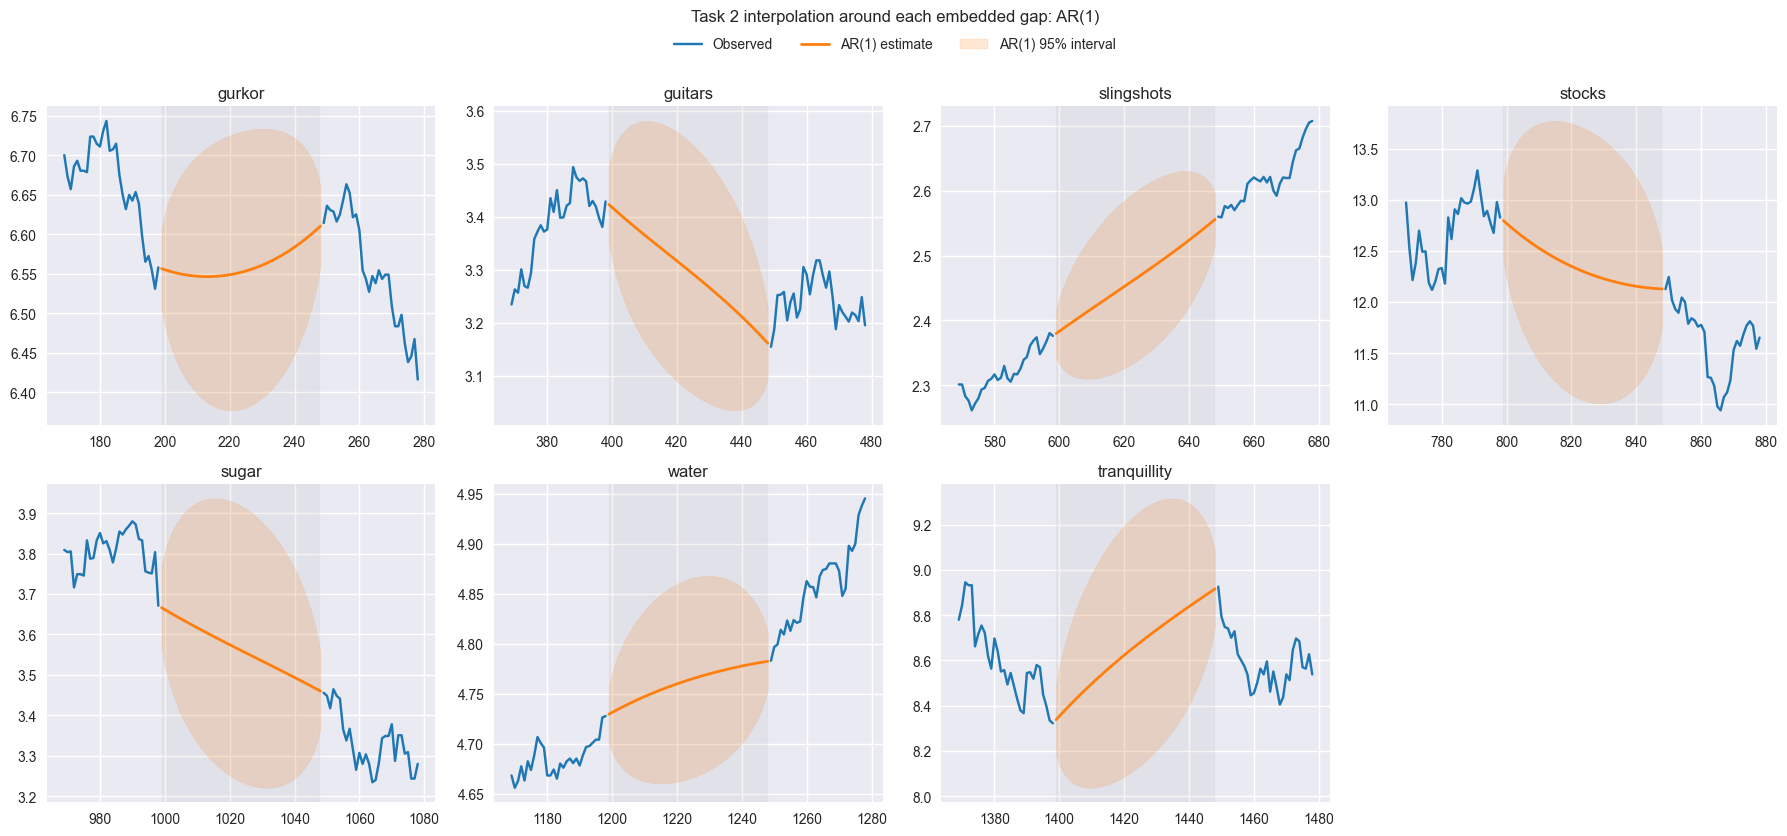

In [6]:
display_interpolation_method("ar1")


### Random Walk
This section reports the random walk bridge estimates, the 95% interval for each imputed point, and the gap plots for all series.


Interpolated values with 95% uncertainty bands: Random walk


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5591,6.5090,6.6096,0.0039
1,200,gurkor,6.5602,6.4902,6.6310,0.0055
2,201,gurkor,6.5613,6.4765,6.6472,0.0066
3,202,gurkor,6.5624,6.4656,6.6607,0.0076
4,203,gurkor,6.5635,6.4565,6.6723,0.0084
5,204,gurkor,6.5646,6.4487,6.6826,0.0091
6,205,gurkor,6.5657,6.4420,6.6918,0.0097
7,206,gurkor,6.5668,6.4361,6.7002,0.0103
8,207,gurkor,6.5679,6.4310,6.7078,0.0108
9,208,gurkor,6.5690,6.4264,6.7148,0.0112



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma,arx_used,arx_source,arx_terms,arx_sigma,arx_fallback_reason
0,gurkor,Random walk,199,248,NaN,NaN,NaN,0.2908,-0.0001,0.0039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,guitars,Random walk,399,448,NaN,NaN,NaN,0.3793,0.0003,0.0103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,slingshots,Random walk,599,648,NaN,NaN,NaN,0.1970,0.0001,0.0071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,stocks,Random walk,799,848,NaN,NaN,NaN,2.2042,-0.0004,0.0158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sugar,Random walk,999,1048,NaN,NaN,NaN,0.5546,-0.0001,0.0139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,water,Random walk,1199,1248,NaN,NaN,NaN,0.1629,0.0004,0.0031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,tranquillity,Random walk,1399,1448,NaN,NaN,NaN,0.8752,-0.0003,0.0091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


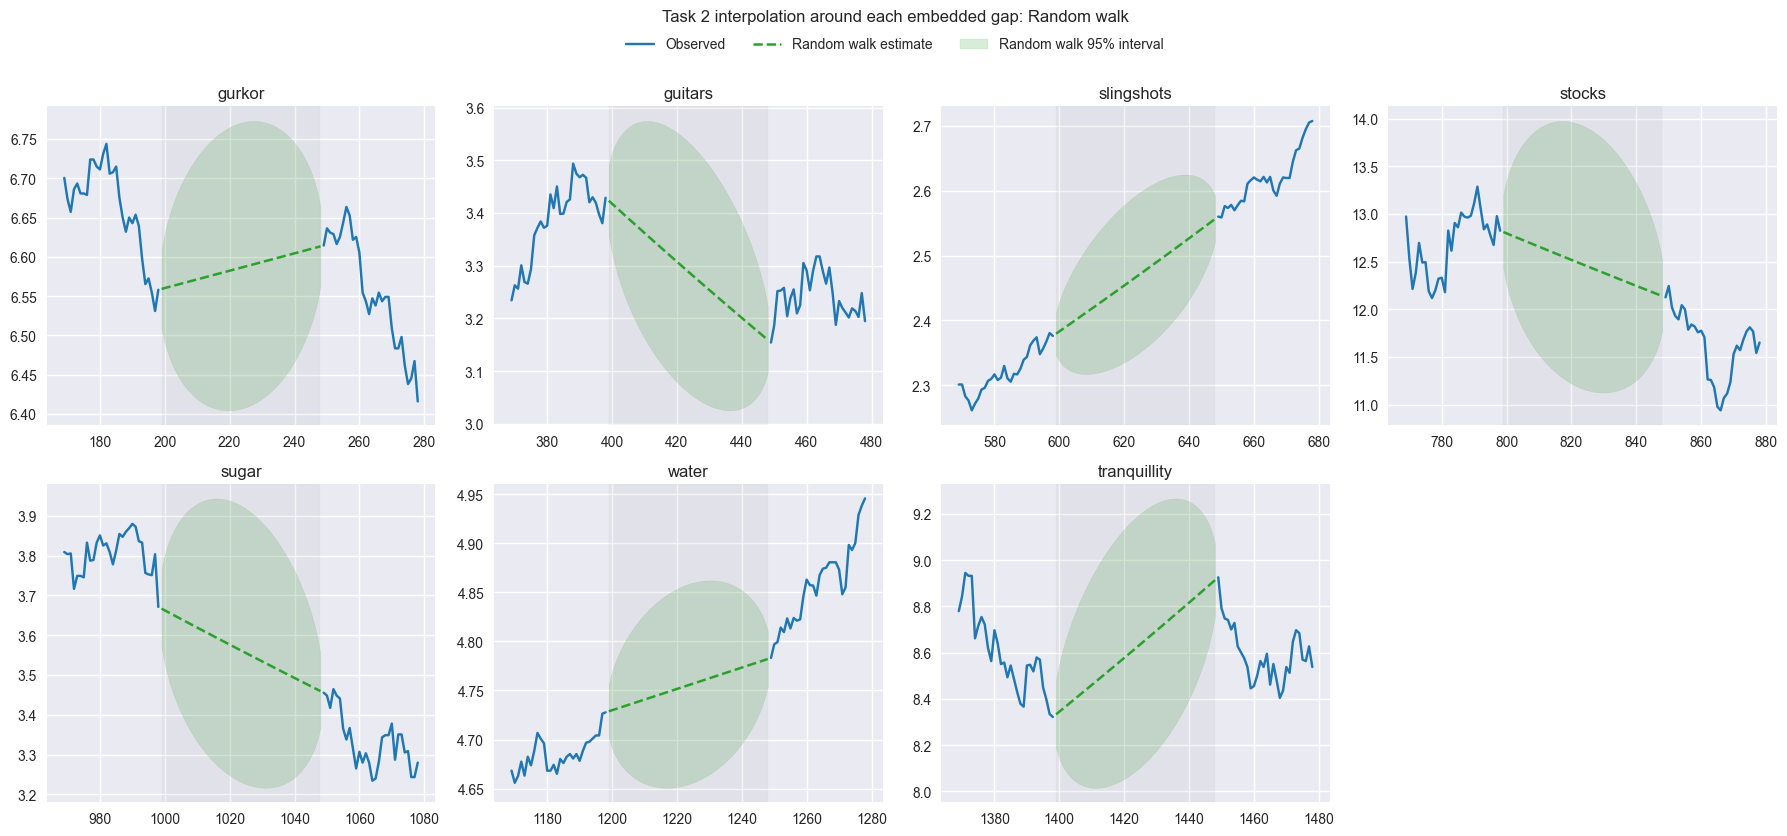

In [7]:
display_interpolation_method("random_walk")


### GARCH(1,1)
This section reports the GARCH(1,1) bridge estimates, the 95% interval for each imputed point, and the gap plots for all series.


Interpolated values with 95% uncertainty bands: GARCH(1,1)


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5597,6.5208,6.5987,0.0030
1,200,gurkor,6.5613,6.5075,6.6155,0.0042
2,201,gurkor,6.5628,6.4983,6.6279,0.0050
3,202,gurkor,6.5643,6.4914,6.6381,0.0057
4,203,gurkor,6.5658,6.4860,6.6466,0.0062
5,204,gurkor,6.5673,6.4817,6.6540,0.0067
6,205,gurkor,6.5687,6.4782,6.6606,0.0071
7,206,gurkor,6.5701,6.4754,6.6663,0.0074
8,207,gurkor,6.5715,6.4731,6.6715,0.0077
9,208,gurkor,6.5729,6.4713,6.6761,0.0079



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma,arx_used,arx_source,arx_terms,arx_sigma,arx_fallback_reason
0,gurkor,"GARCH(1,1)",199,248,NaN,NaN,NaN,0.1857,0.0000,NaN,0.0000,0.0800,0.8800,0.0020,NaN,NaN,NaN,NaN,NaN
1,guitars,"GARCH(1,1)",399,448,NaN,NaN,NaN,0.2536,0.0005,NaN,0.0000,0.0800,0.8800,0.0059,NaN,NaN,NaN,NaN,NaN
2,slingshots,"GARCH(1,1)",599,648,NaN,NaN,NaN,0.1118,0.0009,NaN,0.0000,0.0800,0.8800,0.0036,NaN,NaN,NaN,NaN,NaN
3,stocks,"GARCH(1,1)",799,848,NaN,NaN,NaN,1.6325,-0.0002,NaN,0.0000,0.0800,0.8800,0.0102,NaN,NaN,NaN,NaN,NaN
4,sugar,"GARCH(1,1)",999,1048,NaN,NaN,NaN,0.3568,0.0003,NaN,0.0000,0.0800,0.8800,0.0055,NaN,NaN,NaN,NaN,NaN
5,water,"GARCH(1,1)",1199,1248,NaN,NaN,NaN,0.0813,0.0004,NaN,0.0000,0.0800,0.8800,0.0013,NaN,NaN,NaN,NaN,NaN
6,tranquillity,"GARCH(1,1)",1399,1448,NaN,NaN,NaN,0.5712,-0.0005,NaN,0.0000,0.0800,0.8800,0.0047,NaN,NaN,NaN,NaN,NaN


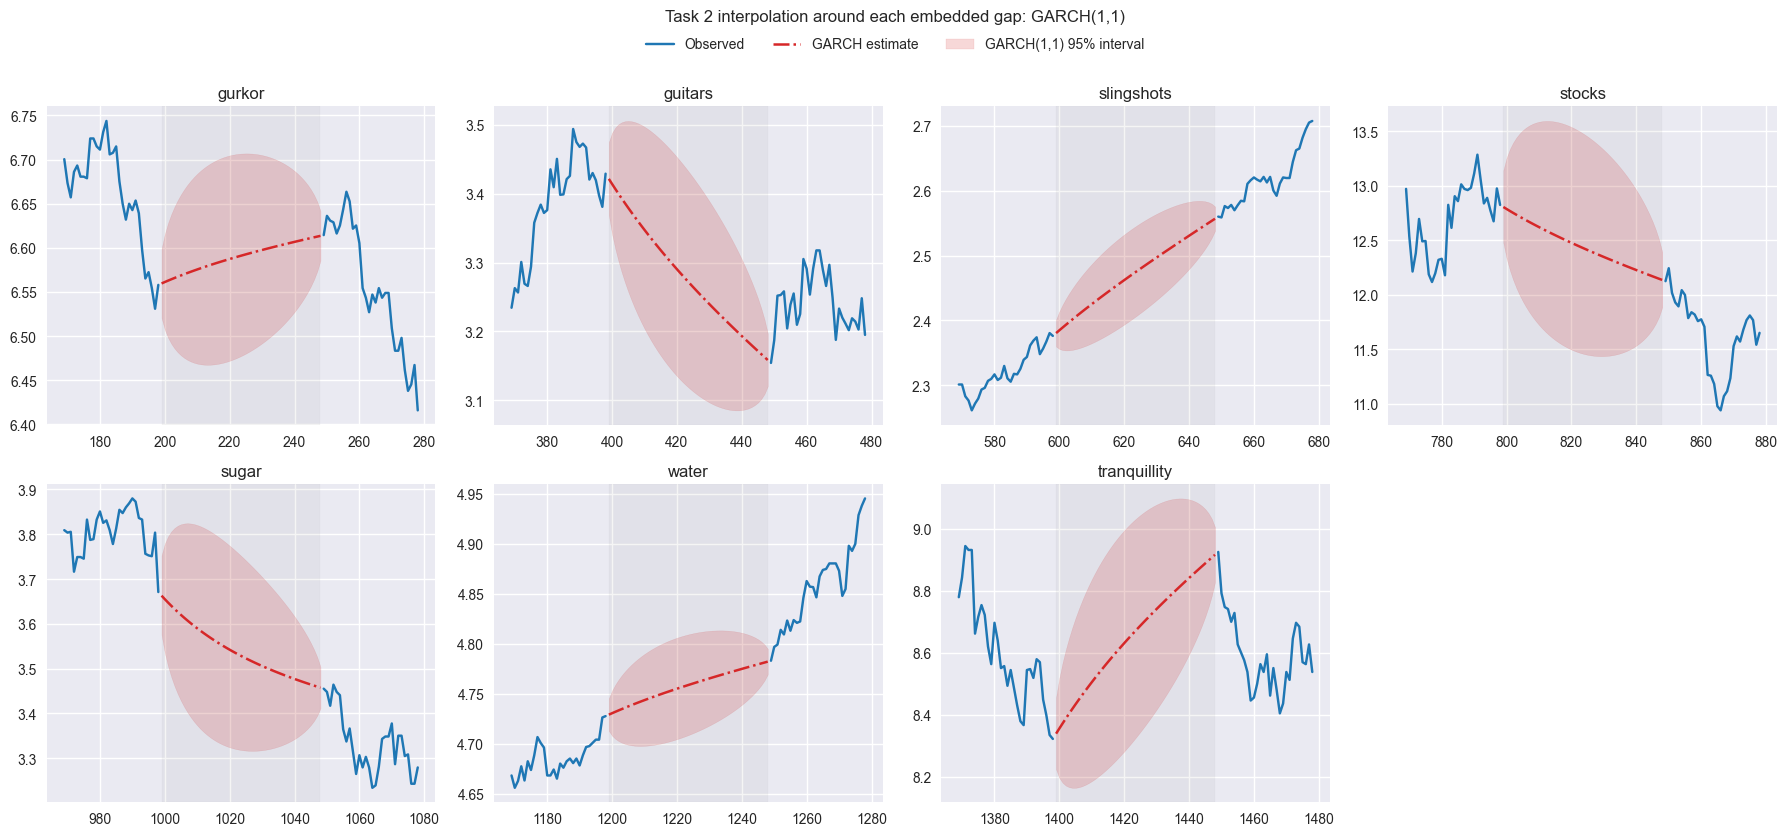

In [8]:
display_interpolation_method("garch")


### AR-X (Task 1 exog)
This section reports the statsmodels AR model augmented with lagged exogenous variables selected from Task 1. The selected exogenous variables are shown in the model summary table through the `arx_terms` column.


Interpolated values with 95% uncertainty bands: AR-X (Task 1 exog)


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5594,6.5095,6.6097,0.0039
1,200,gurkor,6.5616,6.4918,6.6321,0.0055
2,201,gurkor,6.5613,6.4768,6.6469,0.0066
3,202,gurkor,6.5648,6.4683,6.6628,0.0076
4,203,gurkor,6.5650,6.4583,6.6734,0.0084
5,204,gurkor,6.5635,6.4480,6.6811,0.0091
6,205,gurkor,6.5672,6.4439,6.6930,0.0097
7,206,gurkor,6.5717,6.4413,6.7048,0.0102
8,207,gurkor,6.5702,6.4336,6.7097,0.0107
9,208,gurkor,6.5746,6.4323,6.7200,0.0112



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma,arx_used,arx_source,arx_terms,arx_sigma,arx_fallback_reason
0,gurkor,AR-X (Task 1 exog),199,248,NaN,NaN,NaN,0.2901,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation + Granger,"water_lag5, water_lag6, sugar_lag9, sugar_lag10",0.0039,NaN
1,guitars,AR-X (Task 1 exog),399,448,NaN,NaN,NaN,0.4320,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation + Granger,"slingshots_lag2, slingshots_lag3, gurkor_lag1,...",0.0118,NaN
2,slingshots,AR-X (Task 1 exog),599,648,NaN,NaN,NaN,0.2209,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation + Granger,"guitars_lag7, guitars_lag8, sugar_lag4, sugar_...",0.0080,NaN
3,stocks,AR-X (Task 1 exog),799,848,NaN,NaN,NaN,2.2042,NaN,NaN,NaN,NaN,NaN,NaN,False,Task 1 correlation + Granger,fallback: random walk,0.0158,no Task 1 correlation + Granger exogenous regr...
4,sugar,AR-X (Task 1 exog),999,1048,NaN,NaN,NaN,0.5520,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation + Granger,"guitars_lag1, guitars_lag2, tranquillity_lag1,...",0.0138,NaN
5,water,AR-X (Task 1 exog),1199,1248,NaN,NaN,NaN,0.1685,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation + Granger,"gurkor_lag1, gurkor_lag2, sugar_lag9, sugar_lag10",0.0032,NaN
6,tranquillity,AR-X (Task 1 exog),1399,1448,NaN,NaN,NaN,0.9160,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation + Granger,"slingshots_lag1, slingshots_lag2, sugar_lag3, ...",0.0095,NaN


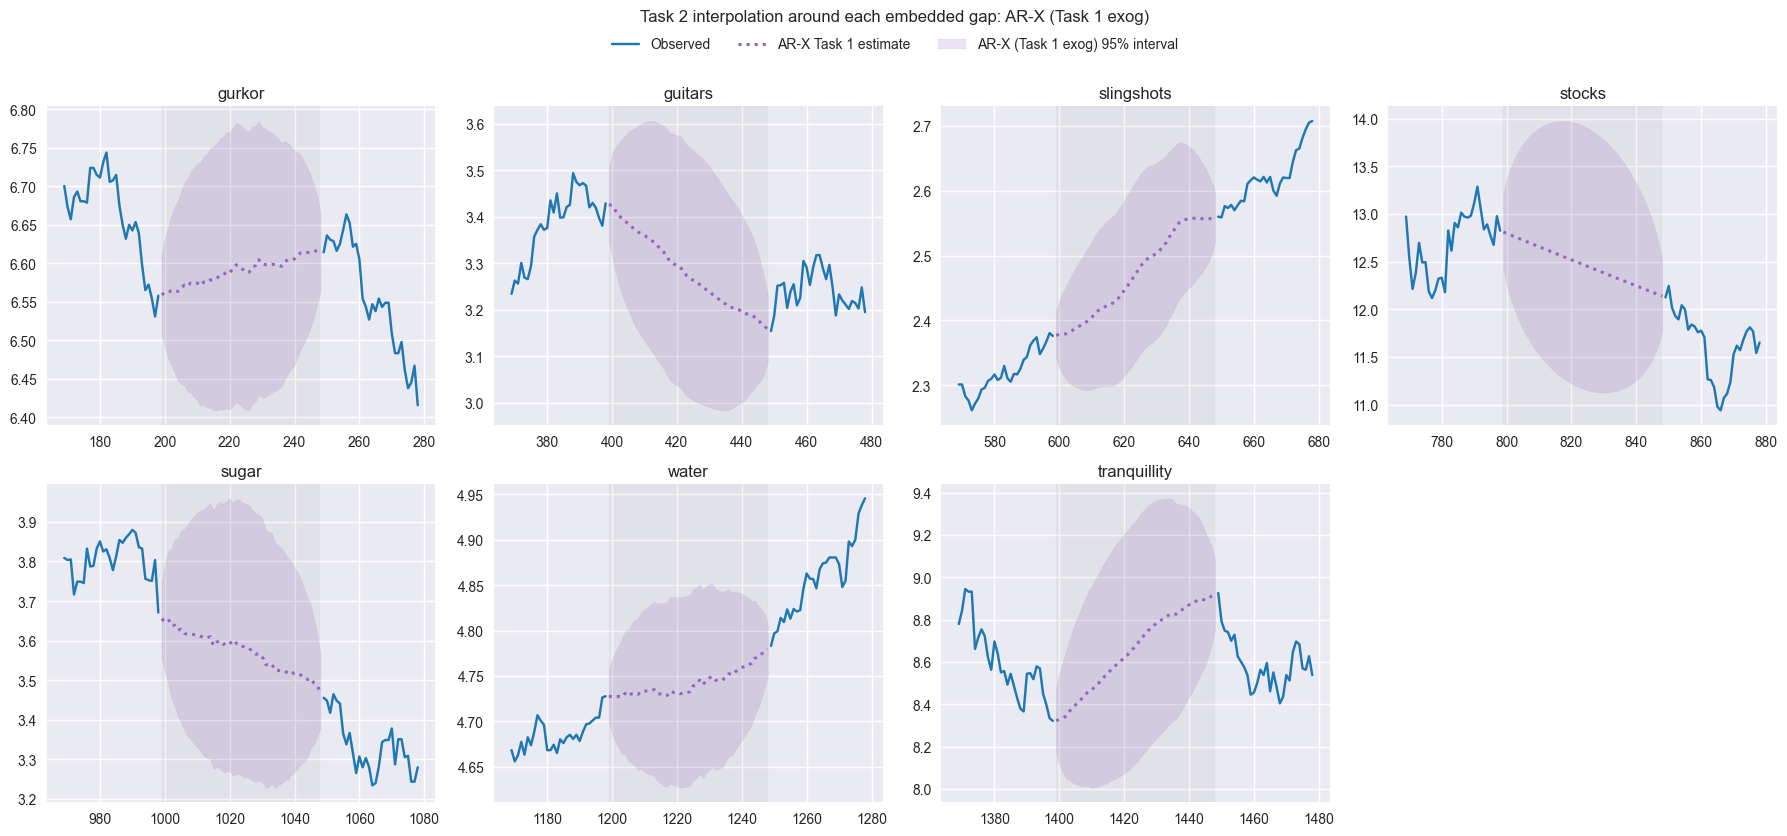

In [9]:
display_interpolation_method("arx_task1")

### AR-X (correlation-only)
This section reports the stricter statsmodels AR-X model that only uses highly correlated Task 1 pairs. It ignores Granger-only predictors and uses lag 1 for each selected correlated driver. The selected exogenous variables are shown in the model summary table through the `arx_terms` column.


Interpolated values with 95% uncertainty bands: AR-X (correlation-only)


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5584,6.5083,6.6088,0.0039
1,200,gurkor,6.5590,6.4890,6.6297,0.0055
2,201,gurkor,6.5594,6.4746,6.6453,0.0066
3,202,gurkor,6.5599,6.4631,6.6581,0.0076
4,203,gurkor,6.5604,6.4535,6.6692,0.0084
5,204,gurkor,6.5611,6.4453,6.6791,0.0091
6,205,gurkor,6.5619,6.4382,6.6880,0.0097
7,206,gurkor,6.5627,6.4321,6.6960,0.0103
8,207,gurkor,6.5637,6.4268,6.7035,0.0108
9,208,gurkor,6.5646,6.4221,6.7103,0.0112



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma,arx_used,arx_source,arx_terms,arx_sigma,arx_fallback_reason
0,gurkor,AR-X (correlation-only),199,248,NaN,NaN,NaN,0.2907,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation-only,water_lag1,0.0040,NaN
1,guitars,AR-X (correlation-only),399,448,NaN,NaN,NaN,0.4154,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation-only,slingshots_lag1,0.0113,NaN
2,slingshots,AR-X (correlation-only),599,648,NaN,NaN,NaN,0.2212,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation-only,guitars_lag1,0.0080,NaN
3,stocks,AR-X (correlation-only),799,848,NaN,NaN,NaN,2.2042,NaN,NaN,NaN,NaN,NaN,NaN,False,Task 1 correlation-only,fallback: random walk,0.0158,no Task 1 correlation-only exogenous regressor...
4,sugar,AR-X (correlation-only),999,1048,NaN,NaN,NaN,0.5546,NaN,NaN,NaN,NaN,NaN,NaN,False,Task 1 correlation-only,fallback: random walk,0.0139,no Task 1 correlation-only exogenous regressor...
5,water,AR-X (correlation-only),1199,1248,NaN,NaN,NaN,0.1649,NaN,NaN,NaN,NaN,NaN,NaN,True,Task 1 correlation-only,gurkor_lag1,0.0031,NaN
6,tranquillity,AR-X (correlation-only),1399,1448,NaN,NaN,NaN,0.8752,NaN,NaN,NaN,NaN,NaN,NaN,False,Task 1 correlation-only,fallback: random walk,0.0091,no Task 1 correlation-only exogenous regressor...


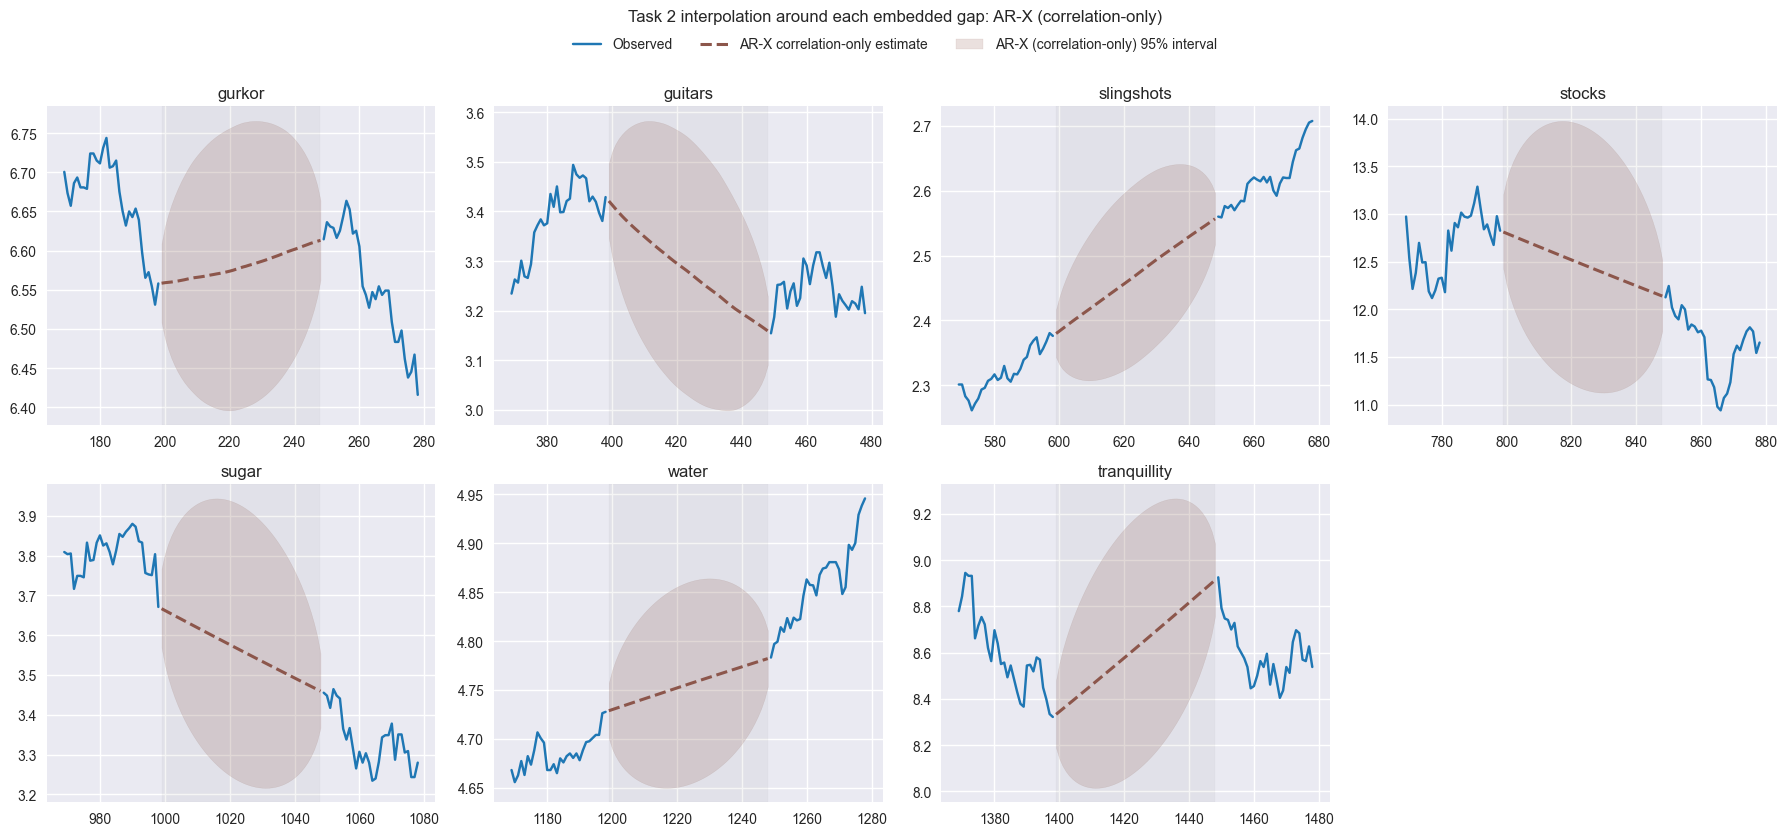

In [10]:
display_interpolation_method("arx_corr_only")


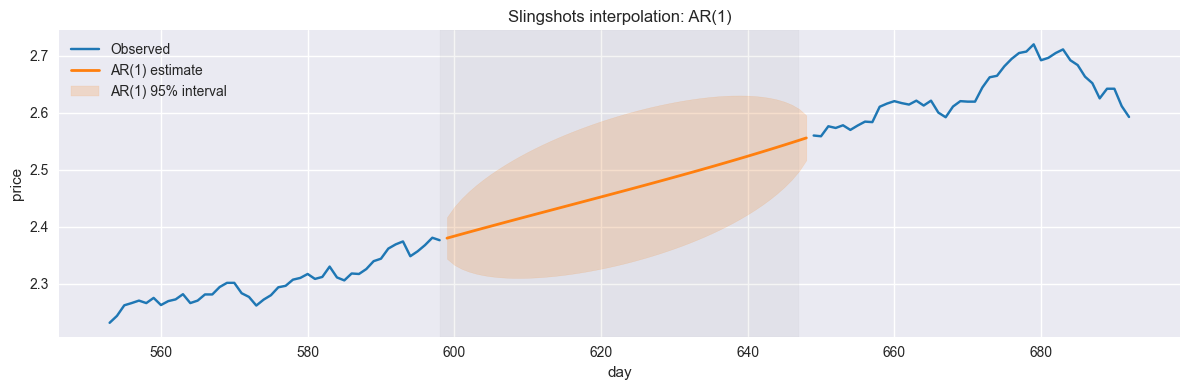

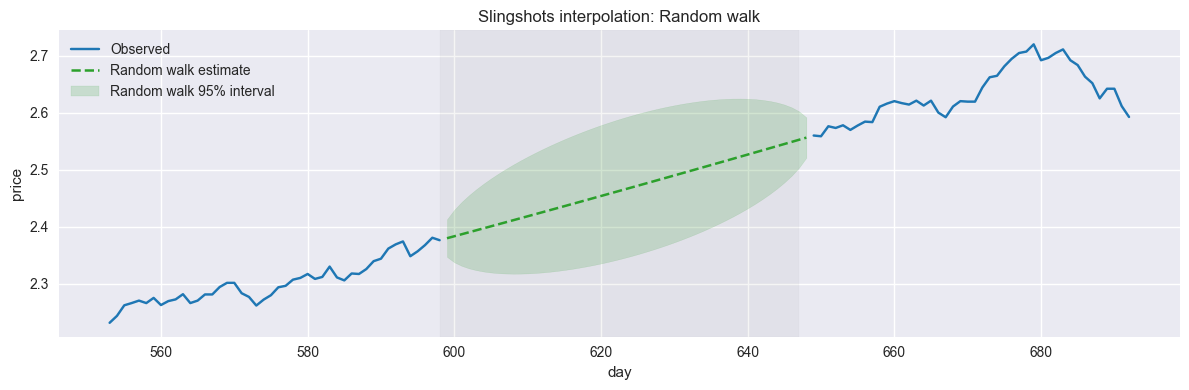

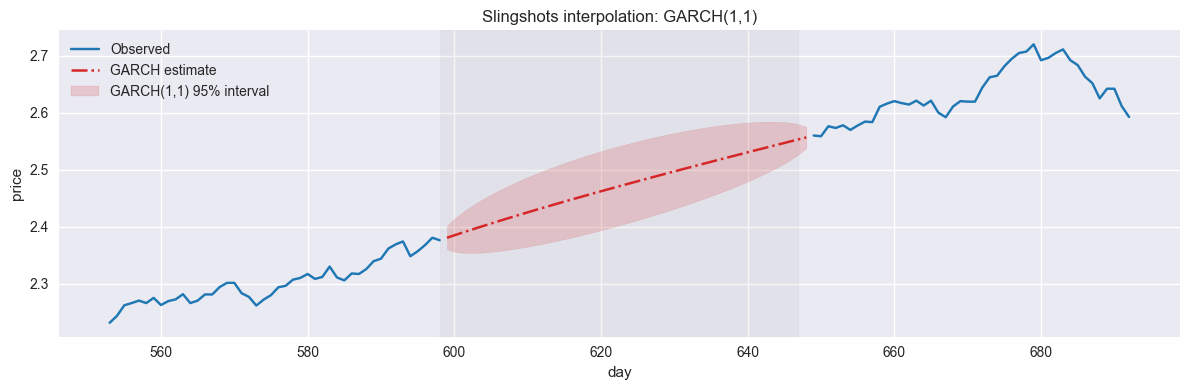

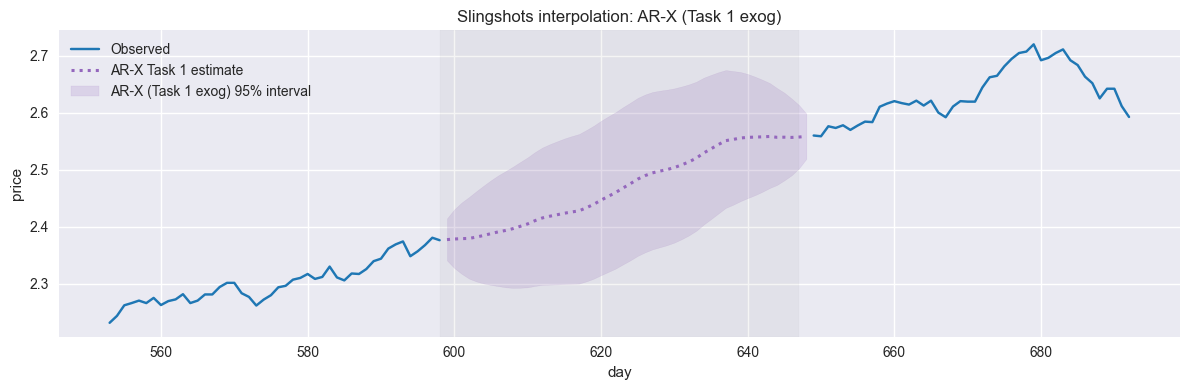

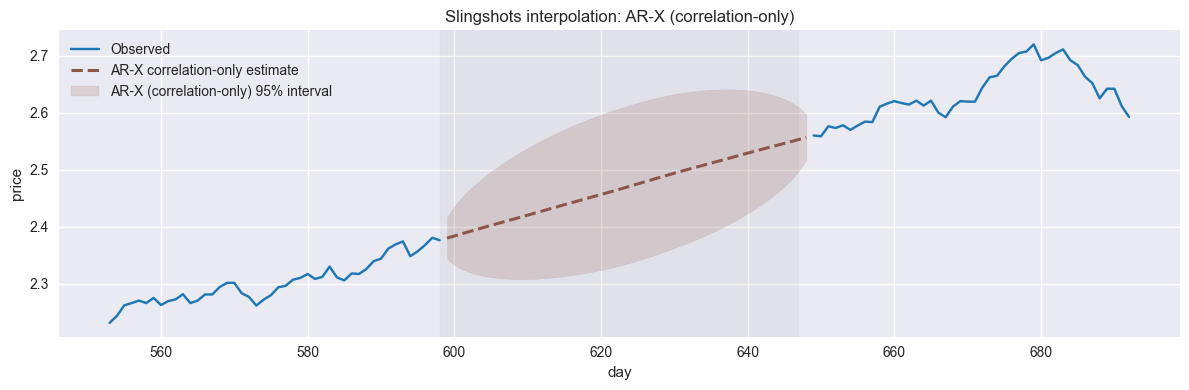

In [11]:
slingshot_series = "slingshots"
slingshot_gap = gap_map[slingshot_series]
slingshot_gap_start, slingshot_gap_end = int(slingshot_gap[0]), int(slingshot_gap[-1])
slingshot_window_days = 45

slingshot_left = max(int(data.index.min()), slingshot_gap_start - slingshot_window_days)
slingshot_right = min(int(known_data.index.max()), slingshot_gap_end + slingshot_window_days)
slingshot_observed = data.loc[slingshot_left:slingshot_right, slingshot_series]

for method in INTERPOLATION_METHODS:
    gap_table = method_tables[method][method_tables[method]["series"] == slingshot_series].set_index("day")
    style = method_styles[method]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(slingshot_observed.index, slingshot_observed.values, color="tab:blue", label="Observed")
    ax.plot(
        gap_table.index,
        gap_table["estimate"],
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        label=style["label"],
    )
    ax.fill_between(
        gap_table.index,
        gap_table["lower_95"],
        gap_table["upper_95"],
        color=style["color"],
        alpha=0.18,
        label=f"{METHOD_LABELS[method]} 95% interval",
    )
    ax.axvspan(slingshot_gap_start, slingshot_gap_end, color="grey", alpha=0.08)
    ax.set_title(f"Slingshots interpolation: {METHOD_LABELS[method]}")
    ax.set_xlabel("day")
    ax.set_ylabel("price")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


## Leakage-safe evaluation
Each method is evaluated on synthetic 50-day gaps inserted into observed parts of the data. For every pseudo-gap, the model only uses information available outside the removed block, so the backtest matches the interpolation setting without leaking the true values.

The main metrics are:
- **MAE** and **RMSE** for reconstruction error.
- **95% coverage** for interval calibration.


In [12]:
def observed_segments_without_tail(series, tail_missing = TAIL_MISSING):
    # keep only observed segments that can be used for pseudo gaps
    trimmed = series.iloc[:-tail_missing]
    observed_groups = contiguous_groups(trimmed.notna())
    return [trimmed.iloc[group] for group in observed_groups if len(group) > 0]


def _backtest_interpolation_for_segment(segment, pseudo_series, start, end, method, gap_length, window, panel_segment):
    # apply one model to one synthetic gap
    log_segment = np.log(segment)
    left_log_price = float(log_segment.iloc[start - 1])
    right_log_price = float(log_segment.iloc[end + 1])

    if method == "ar1":
        mu, phi, sigma_eps = estimate_local_ar1_params(pseudo_series, start, end, window=window)
        estimate, lower_95, upper_95, _ = ar1_conditional_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            mu=mu,
            phi=phi,
            sigma_eps=sigma_eps,
            gap_length=gap_length,
        )
        diagnostics = {
            "local_phi": phi,
            "innovation_sigma": sigma_eps,
        }
    elif method == "random_walk":
        drift, sigma_return = estimate_local_random_walk_params(pseudo_series, start, end, window=window)
        innovation_variances = np.full(gap_length + 1, sigma_return**2)
        estimate, lower_95, upper_95, _ = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        diagnostics = {
            "drift_return": drift,
            "return_sigma": sigma_return,
        }
    elif method == "garch":
        params = estimate_local_garch_params(pseudo_series, start, end, window=window)
        innovation_variances = forecast_garch_innovation_variances(
            last_variance=params["last_variance"],
            omega=params["garch_omega"],
            alpha=params["garch_alpha"],
            beta=params["garch_beta"],
            horizon=gap_length + 1,
        )
        estimate, lower_95, upper_95, _ = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        diagnostics = {
            "drift_return": params["drift_return"],
            "long_run_sigma": params["long_run_sigma"],
        }
    elif method in ("arx_task1", "arx_corr_only"):
        exog_lag_map = TASK1_EXOGENOUS_LAGS if method == "arx_task1" else TASK1_CORRELATION_ONLY_LAGS
        model_source = "Task 1 correlation + Granger" if method == "arx_task1" else "Task 1 correlation-only"
        estimate, lower_95, upper_95, _, params = arx_task1_conditional_prices(
            series=pseudo_series,
            panel_data=panel_segment,
            gap_start=start,
            gap_end=end,
            window=window,
            exog_lag_map=exog_lag_map,
            model_source=model_source,
        )
        diagnostics = params
    else:
        raise ValueError(f"Unknown method: {method}")

    return estimate, lower_95, upper_95, diagnostics


def backtest_series(series, method, gap_length = GAP_LENGTH, window = LOCAL_WINDOW, step = 100):
    # repeat the synthetic gap test across one series
    rows = []

    for segment in observed_segments_without_tail(series):
        if len(segment) < 2 * window + gap_length + 2:
            continue

        panel_segment = data.loc[segment.index]

        for start in range(window, len(segment) - window - gap_length - 1, step):
            end = start + gap_length - 1
            pseudo_series = segment.copy()
            pseudo_series.iloc[start:end + 1] = np.nan

            estimate, lower_95, upper_95, diagnostics = _backtest_interpolation_for_segment(
                segment=segment,
                pseudo_series=pseudo_series,
                start=start,
                end=end,
                method=method,
                gap_length=gap_length,
                window=window,
                panel_segment=panel_segment,
            )

            actual = segment.iloc[start:end + 1].to_numpy()
            rows.append(
                {
                    "series": series.name,
                    "method": METHOD_LABELS[method],
                    "segment_start_day": int(segment.index[start]),
                    "segment_end_day": int(segment.index[end]),
                    **diagnostics,
                    "mae": float(np.mean(np.abs(actual - estimate))),
                    "rmse": float(np.sqrt(np.mean((actual - estimate) ** 2))),
                    "coverage_95": float(np.mean((actual >= lower_95) & (actual <= upper_95))),
                }
            )

    return pd.DataFrame(rows)


# aggregate backtest results across all models and series
backtest_results = pd.concat(
    [
        backtest_series(data[column], method=method)
        for method in INTERPOLATION_METHODS
        for column in data.columns
    ],
    ignore_index=True,
)
backtest_summary = backtest_results.groupby(["method", "series"], as_index=False).agg(
    mean_mae=("mae", "mean"),
    mean_rmse=("rmse", "mean"),
    mean_coverage_95=("coverage_95", "mean"),
    pseudo_gap_count=("coverage_95", "size"),
)
backtest_method_summary = backtest_results.groupby("method", as_index=False).agg(
    overall_mae=("mae", "mean"),
    overall_rmse=("rmse", "mean"),
    overall_coverage_95=("coverage_95", "mean"),
    pseudo_gap_count=("coverage_95", "size"),
)
backtest_method_summary["coverage_gap"] = (backtest_method_summary["overall_coverage_95"] - 0.95).abs()
backtest_method_summary = backtest_method_summary.sort_values(
    ["overall_rmse", "overall_mae", "coverage_gap"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(backtest_summary)
display(backtest_method_summary)


/Users/albinessman/Chalmers/fts/project_FTS/.venv/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


,method,series,mean_mae,mean_rmse,mean_coverage_95,pseudo_gap_count
0,AR(1),guitars,0.1735,0.2109,0.9660,43
1,AR(1),gurkor,0.0793,0.0943,0.9502,45
2,AR(1),slingshots,0.1016,0.1228,0.9652,42
3,AR(1),stocks,0.1985,0.2400,0.9548,42
4,AR(1),sugar,0.0737,0.0874,0.9571,42
...,...,...,...,...,...,...
30,Random walk,slingshots,0.0960,0.1169,0.9710,42
31,Random walk,stocks,0.1941,0.2339,0.9529,42
32,Random walk,sugar,0.0740,0.0883,0.9576,42
33,Random walk,tranquillity,0.3031,0.3675,0.9676,42


,method,overall_mae,overall_rmse,overall_coverage_95,pseudo_gap_count,coverage_gap
0,AR-X (Task 1 exog),0.1341,0.1612,0.9653,298,0.0153
1,Random walk,0.1364,0.1647,0.9572,298,0.0072
2,AR-X (correlation-only),0.1375,0.1658,0.9590,298,0.0090
3,AR(1),0.1395,0.1683,0.9568,298,0.0068
4,"GARCH(1,1)",0.1428,0.1714,0.7997,298,0.1503


## Result
The table below ranks all interpolation methods, including both Task 1 AR-X extensions. The main selection criterion is overall RMSE, with MAE and 95% coverage used as supporting checks.


In [13]:
# pick the top ranked model from the backtest table
best_method = backtest_method_summary.iloc[0]
best_method_name = best_method["method"]

result_table = backtest_method_summary.copy()
result_table["is_best"] = ["best" if idx == 0 else "" for idx in result_table.index]

display(result_table)
print(
    f"Best solution: {best_method_name} "
    f"(RMSE={best_method['overall_rmse']:.4f}, "
    f"MAE={best_method['overall_mae']:.4f}, "
    f"coverage={best_method['overall_coverage_95']:.3f})."
)


,method,overall_mae,overall_rmse,overall_coverage_95,pseudo_gap_count,coverage_gap,is_best
0,AR-X (Task 1 exog),0.1341,0.1612,0.9653,298,0.0153,best
1,Random walk,0.1364,0.1647,0.9572,298,0.0072,
2,AR-X (correlation-only),0.1375,0.1658,0.9590,298,0.0090,
3,AR(1),0.1395,0.1683,0.9568,298,0.0068,
4,"GARCH(1,1)",0.1428,0.1714,0.7997,298,0.1503,


Best solution: AR-X (Task 1 exog) (RMSE=0.1612, MAE=0.1341, coverage=0.965).
